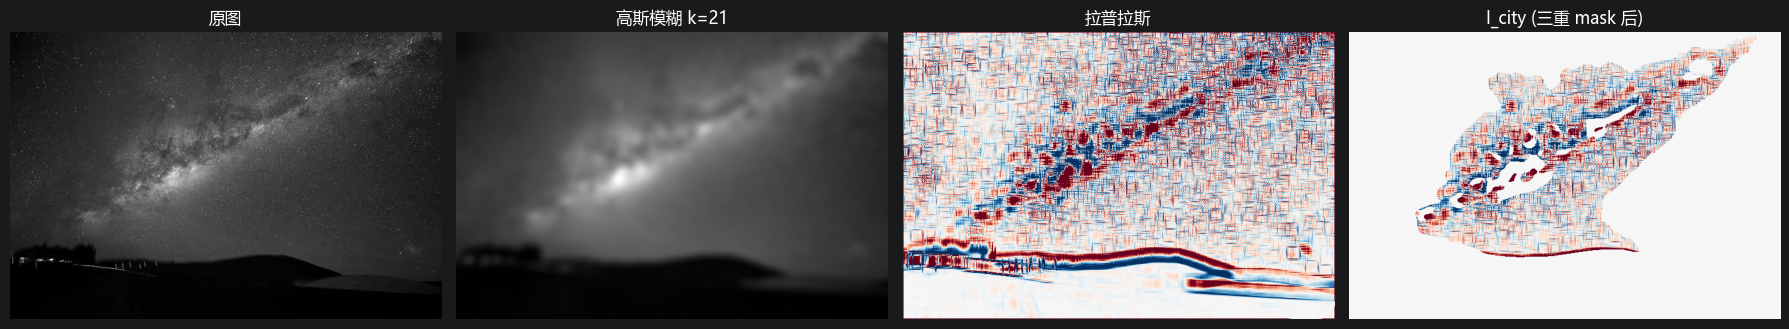

In [10]:
import torch
import numpy as np
import torch.nn.functional as F_conv
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

# 中文字体 (Windows 用 SimHei, 没装就退化到默认)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False   # 负号显示

import pinn_starlight_core.data.PhotoLoader as Loader

# ============ 1. 读取图片，转灰度 ============
loader = Loader.RAWLoader()
loader.load(r"../../data/real_raw/origin/03.jpg")
gray_img = np.mean(loader.rgb_data, axis=2).astype(np.float32)   # (H, W) 灰度 numpy
H, W = gray_img.shape
# 转成 (1, 1, H, W) 给 PyTorch 卷积用: (batch, channel, height, width)
img_tensor = torch.from_numpy(gray_img).unsqueeze(0).unsqueeze(0)

# ============ 2. 高斯模糊 → 抹掉星点，留光污染 ============
kernel_size = 21
sigma = kernel_size / 3.0   # 经验法则: sigma ≈ kernel/3
blurred = F.gaussian_blur(img_tensor, [kernel_size, kernel_size],
                          sigma=[sigma, sigma]).squeeze()   # → (H, W)

# ============ 3. 拉普拉斯 ∇² → 找亮度变化最剧烈的地方 ============
# 拉普拉斯核: 中心 -4, 上下左右各 +1, 加起来=0
# 在均匀区域响应=0, 在凸起(光源中心)响应为负, 在凹陷(暗斑中心)响应为正
laplacian_kernel = torch.tensor([[0., 1., 0.],
                                  [1., -4., 1.],
                                  [0., 1., 0.]])
laplacian = F_conv.conv2d(blurred.unsqueeze(0).unsqueeze(0),
                          laplacian_kernel.view(1, 1, 3, 3),
                          padding=1).squeeze()   # padding=1 保持尺寸不变

# ============ 4. 三重门限: 只保留地平线附近的"真光源"信号 ============

# (a) 亮度门限: 只留最亮的 30% 区域 (地平线/城市灯光)
bright_mask = (blurred > blurred.quantile(0.70)).float()

# (b) 垂直衰减: 天顶权重=0, 地平线权重=1
# 光污染随高度指数衰减, 星云不受这规律约束 → 用这个压星云
y_axis = torch.linspace(0, 1, H)              # 0=图顶(天顶), 1=图底(地平线)
vertical_decay = (1 - torch.exp(-y_axis * 6))[:, None]   # (H, 1) → 自动广播到 (H, W)

# (c) 边缘置零: 砍掉梯度幅度 top 5% 的像素 (建筑剪影边缘/星点核心)
# 这些地方拉普拉斯会爆, 但不是光污染源
gy, gx = torch.gradient(blurred)
gradient_magnitude = torch.sqrt(gx**2 + gy**2)
edge_mask = (gradient_magnitude < gradient_magnitude.quantile(0.95)).float()

# 三重 mask 相乘
icity = laplacian * bright_mask * vertical_decay * edge_mask

# ============ 5. 显示 ============
# 用 98% 分位裁剪极端值, 否则图被极值拉成一片白
display_range = np.percentile(icity.abs().numpy(), 98)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(gray_img, cmap='gray');       ax[0].set_title('原图')
ax[1].imshow(blurred, cmap='gray');        ax[1].set_title(f'高斯模糊 k={kernel_size}')
ax[2].imshow(laplacian, cmap='RdBu',
             vmin=-display_range, vmax=display_range);  ax[2].set_title('拉普拉斯')
ax[3].imshow(icity, cmap='RdBu',
             vmin=-display_range, vmax=display_range);  ax[3].set_title('I_city (三重 mask 后)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

In [11]:
from pinn_starlight_core.nn import Icity
import os
import torch
from torch import optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import pinn_starlight_core.nn.Layers as Layers
import pinn_starlight_core.nn.Losses as Loss
import pinn_starlight_core.data.PhotoLoader as RAWLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dir  = '../../data/real_raw/origin'
output_dir = '../../data/real_raw/trained'
os.makedirs(output_dir, exist_ok=True)

for file in sorted(os.listdir(input_dir)):
    path = os.path.join(input_dir, file)
    base = file.rsplit('.', 1)[0]
    print(f'Processing {file}...')

    loader = RAWLoader.RAWLoader()
    loader.load(path)
    coords, values, W, H = loader.get_gray_data(device)

    layers = [
        Layers.SkyglowLinear(2, 512).to(device),
        Layers.SkyglowActivation(),
        Layers.SkyglowLinear(512, 64).to(device),
        Layers.SkyglowActivation(),
        Layers.SkyglowLinear(64, 1).to(device),
    ]

    params = []
    for layer in layers:
        if isinstance(layer, Layers.SkyglowLinear):
            params += list(layer.parameters())

    ld = Loss.MSEData()
    lp = Loss.MSEPhysics()

    alpha = torch.nn.Parameter(torch.tensor(1.0, device=device))

    I_city_field = Icity.Icity(path, device).get_icity()   # (H, W) 常数张量
    I_city_flat = I_city_field.flatten()                   # (H*W,) 跟 coords/values 对齐
    phy_weight = 0.1

    optimizer = optim.Adam(
        params +
        [alpha],
        lr = 0.001
    )

    for step in tqdm(range(int(coords.shape[0] / 330))):
        idx = torch.randint(0, coords.shape[0], (int(coords.shape[0] / 420),))
        batch_xy = coords[idx].to(device).clone().requires_grad_(True)
        batch_I = values[idx].to(device)

        a = batch_xy
        for layer in layers:
            a = layer.forward(a)
        I_pred = a.squeeze().to(device)

        I_city_vals = I_city_flat[idx]

        data_loss = ld.forward(batch_I, I_pred)
        phys_loss = lp.forward(batch_I, I_pred, I_city_vals, alpha, batch_xy)
        loss = data_loss + phy_weight * phys_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        I_pred = torch.empty(coords.shape[0], device=device)
        for start in range(0, coords.shape[0], 50000):
            end = min(start + 50000, coords.shape[0])
            a = coords[start:end]
            for layer in layers:
                a = layer.forward(a)
            I_pred[start:end] = a.squeeze()

    obs = values.reshape(H, W).cpu().numpy()
    pred = I_pred.reshape(H, W).cpu().numpy()
    res = (obs - pred).clip(0, 1)

    print(f'alpha:{alpha},')
    plt.imsave(f'{output_dir}/{base}_observed.png', obs, cmap='gray')
    plt.imsave(f'{output_dir}/{base}_predicted.png', pred, cmap='gray')
    plt.imsave(f'{output_dir}/{base}_residual.png', res, cmap='gray')

print('Done.')

Processing 01.jpg...


  0%|          | 0/360 [00:00<?, ?it/s]

alpha:Parameter containing:
tensor(0.6868, requires_grad=True),
Processing 02.jpg...


  0%|          | 0/3958 [00:00<?, ?it/s]

KeyboardInterrupt: 